<a href="https://colab.research.google.com/github/GEE2007/world-happiness-clustering/blob/main/world_happiness_clustering.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# **Project Name**    - World Happiness Clustering



##### **Project Type**    - Unsupervised
##### **Contribution**    - Individual
##### **Team Member 1 -** Geetika

# **Project Summary -**

Write the summary here within 500-600 words.

# **GitHub Link -**

https://github.com/GEE2007/world-happiness-clustering

# **Problem Statement**


**Write Problem Statement Here.**

# **General Guidelines** : -  

1.   Well-structured, formatted, and commented code is required.
2.   Exception Handling, Production Grade Code & Deployment Ready Code will be a plus. Those students will be awarded some additional credits.
     
     The additional credits will have advantages over other students during Star Student selection.
       
             [ Note: - Deployment Ready Code is defined as, the whole .ipynb notebook should be executable in one go
                       without a single error logged. ]

3.   Each and every logic should have proper comments.
4. You may add as many number of charts you want. Make Sure for each and every chart the following format should be answered.
        

```
# Chart visualization code
```
            

*   Why did you pick the specific chart?
*   What is/are the insight(s) found from the chart?
* Will the gained insights help creating a positive business impact?
Are there any insights that lead to negative growth? Justify with specific reason.

5. You have to create at least 15 logical & meaningful charts having important insights.


[ Hints : - Do the Vizualization in  a structured way while following "UBM" Rule.

U - Univariate Analysis,

B - Bivariate Analysis (Numerical - Categorical, Numerical - Numerical, Categorical - Categorical)

M - Multivariate Analysis
 ]





6. You may add more ml algorithms for model creation. Make sure for each and every algorithm, the following format should be answered.


*   Explain the ML Model used and it's performance using Evaluation metric Score Chart.


*   Cross- Validation & Hyperparameter Tuning

*   Have you seen any improvement? Note down the improvement with updates Evaluation metric Score Chart.

*   Explain each evaluation metric's indication towards business and the business impact pf the ML model used.




















# ***Let's Begin !***

## ***1. Know Your Data***

### Import Libraries

In [1]:
# Import Libraries
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

### Dataset Loading

In [8]:
# Load Dataset
import os
import kagglehub

# Download latest version
path = kagglehub.dataset_download("claudiodaloiso/world-happiness-report-2005-2024")

print("Path to dataset files:", path)
print(os.listdir(path))
df = pd.read_csv(os.path.join(path, "happy.csv"), sep=";")

Using Colab cache for faster access to the 'world-happiness-report-2005-2024' dataset.
Path to dataset files: /kaggle/input/world-happiness-report-2005-2024
['happy.csv']


### Dataset First View

In [9]:
# Dataset First Look
df.head()

,Data,Rank,Country name,Ladder score,upperwhisker,lowerwhisker,Explained by: Log GDP per capita,Explained by: Social support,Explained by: Healthy life expectancy,Explained by: Freedom to make life choices,Explained by: Generosity,Explained by: Perceptions of corruption,Dystopia + residual
0,01/01/2024,1,Finland,"7,736","7,81","7,662","1,749","1,783","0,824","0,986","0,11","0,502","1,782"
1,01/01/2023,143,Afghanistan,"1,721","1,775","1,667","0,628",0,"0,242",0,"0,091","0,088","0,672"
2,01/01/2022,137,Afghanistan,"1,859","1,923","1,795","0,645",0,"0,087",0,"0,093","0,059","0,976"
3,01/01/2021,146,Afghanistan,"2,404","2,469","2,339","0,758",0,"0,289",0,"0,089","0,005","1,263"
4,01/01/2020,150,Afghanistan,"2,523","2,596","2,449","0,37",0,"0,126",0,"0,122","0,01","1,895"


### Dataset Rows & Columns count

In [10]:
# Dataset Rows & Columns count
df.shape

(1969, 13)

### Dataset Information

In [11]:
# Dataset Info
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1969 entries, 0 to 1968
Data columns (total 13 columns):
 #   Column                                      Non-Null Count  Dtype 
---  ------                                      --------------  ----- 
 0   Data                                        1969 non-null   object
 1   Rank                                        1969 non-null   int64 
 2   Country name                                1969 non-null   object
 3   Ladder score                                1969 non-null   object
 4   upperwhisker                                875 non-null    object
 5   lowerwhisker                                875 non-null    object
 6   Explained by: Log GDP per capita            872 non-null    object
 7   Explained by: Social support                872 non-null    object
 8   Explained by: Healthy life expectancy       870 non-null    object
 9   Explained by: Freedom to make life choices  871 non-null    object
 10  Explained by: Generosity

#### Duplicate Values

In [12]:
# Dataset Duplicate Value Count
df.duplicated().sum()

np.int64(0)

#### Missing Values/Null Values

In [13]:
# Missing Values/Null Values Count
df.isnull().sum()

,0
Data,0
Rank,0
Country name,0
Ladder score,0
upperwhisker,1094
lowerwhisker,1094
Explained by: Log GDP per capita,1097
Explained by: Social support,1097
Explained by: Healthy life expectancy,1099
Explained by: Freedom to make life choices,1098


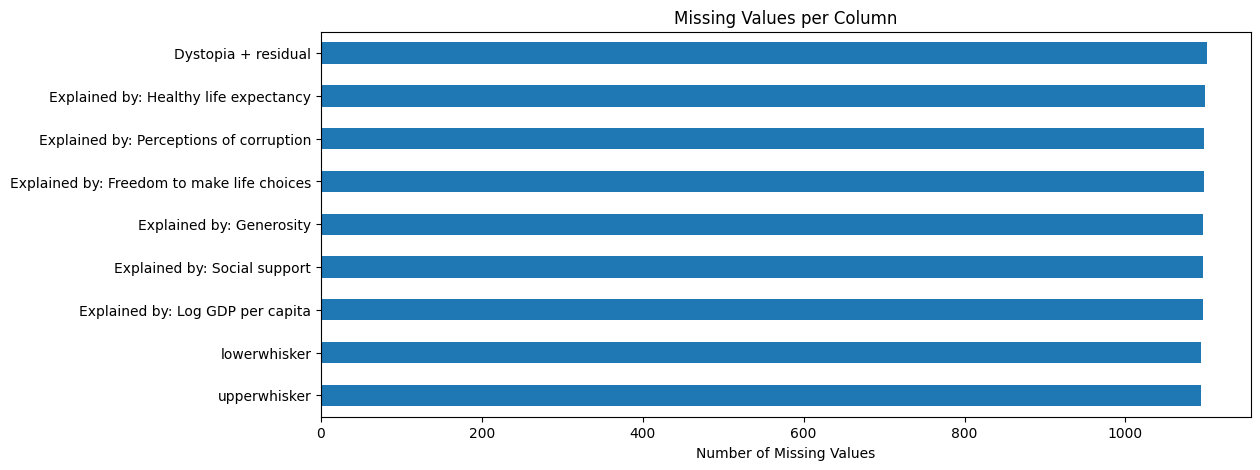

In [16]:
# Visualizing the missing values
missing = df.isnull().sum()

plt.figure(figsize=(12,5))
missing[missing > 0].sort_values().plot(kind="barh")
plt.title("Missing Values per Column")
plt.xlabel("Number of Missing Values")
plt.show()

### What did you know about your dataset?

* *The dataset contains 1,969 rows and 13 columns.*
* *It represents the World Happiness Report rankings for multiple countries across different years.*
* *The dataset includes the happiness score (Ladder score), country ranking, and factors contributing to happiness such as GDP per capita, social support, healthy life expectancy, freedom to make life choices, generosity, perceptions of corruption, and Dystopia + residual.*
* *The dataset contains no duplicate rows (assuming you've checked df.duplicated().sum()).*
* *Several columns have a large number of missing values, particularly the confidence interval (upperwhisker, lowerwhisker) and "Explained by" columns.*
* *The missing values are primarily due to data being unavailable for certain years and reports.*
* *Appropriate preprocessing, including handling missing values and scaling numerical features, is required before applying clustering algorithms.*

## ***2. Understanding Your Variables***

In [17]:
# Dataset Columns
df.columns

Index(['Data', 'Rank', 'Country name', 'Ladder score', 'upperwhisker',
       'lowerwhisker', 'Explained by: Log GDP per capita',
       'Explained by: Social support', 'Explained by: Healthy life expectancy',
       'Explained by: Freedom to make life choices',
       'Explained by: Generosity', 'Explained by: Perceptions of corruption',
       'Dystopia + residual'],
      dtype='object')

In [19]:
# Dataset Describe
df.describe()

,Rank
count,1969.000000
mean,76.430168
std,43.942744
min,1.000000
25%,38.000000
50%,76.000000
75%,114.000000
max,158.000000


### Variables Description

* *Data: Date corresponding to the World Happiness Report.*
* *Rank: Rank of the country based on happiness score.*
* *Country name: Name of the country.*
* *Ladder score: Overall happiness score of the country.*
* *upperwhisker: Upper confidence interval of the happiness score.*
* *lowerwhisker: Lower confidence interval of the happiness score.*
* *Explained by: Log GDP per capita: Contribution of GDP per capita to the happiness score.*
* *Explained by: Social support: Contribution of social support.*
* *Explained by: Healthy life expectancy: Contribution of healthy life expectancy.*
* *Explained by: Freedom to make life choices: Contribution of freedom.*
* *Explained by: Generosity: Contribution of generosity.*
* *Explained by: Perceptions of corruption: Contribution of corruption perception.*
* *Dystopia + residual: Remaining unexplained contribution to the happiness score.*

### Check Unique Values for each variable.

In [21]:
# Check Unique Values for each variable.
for col in df.columns:
    print(f"{col}: {df[col].nunique()} unique values")

Data: 13 unique values
Rank: 158 unique values
Country name: 169 unique values
Ladder score: 1570 unique values
upperwhisker: 813 unique values
lowerwhisker: 794 unique values
Explained by: Log GDP per capita: 728 unique values
Explained by: Social support: 703 unique values
Explained by: Healthy life expectancy: 606 unique values
Explained by: Freedom to make life choices: 581 unique values
Explained by: Generosity: 427 unique values
Explained by: Perceptions of corruption: 461 unique values
Dystopia + residual: 761 unique values


## 3. ***Data Wrangling***

### Data Wrangling Code

In [29]:
# Write your code to make your dataset analysis ready.
df["Data"] = pd.to_datetime(df["Data"])
df["Year"] = df["Data"].dt.year

for col in numeric_cols:
    df[col] = pd.to_numeric(
        df[col].astype(str).str.replace(",", ".", regex=False),
        errors="coerce"
    )


numeric_cols = [
    "Ladder score",
    "upperwhisker",
    "lowerwhisker",
    "Explained by: Log GDP per capita",
    "Explained by: Social support",
    "Explained by: Healthy life expectancy",
    "Explained by: Freedom to make life choices",
    "Explained by: Generosity",
    "Explained by: Perceptions of corruption",
    "Dystopia + residual"
]

for col in numeric_cols:
    df[col] = pd.to_numeric(
        df[col].astype(str).str.replace(",", ".", regex=False),
        errors="coerce"
    )

# Fill missing values with median
df[numeric_cols] = df[numeric_cols].fillna(df[numeric_cols].median())

### What all manipulations have you done and insights you found?

* *Converted the Data column into datetime format and extracted the year.*
* *Converted numerical columns from object to numeric by replacing comma (',') decimal separators with dots ('.').*
* *Checked the dataset for missing values.*
* *Filled missing values in numerical columns using the median of each column.*
* *Checked for duplicate records and found none.*
* *Verified that the dataset was clean and ready for exploratory data analysis and clustering.*



## ***4. Data Vizualization, Storytelling & Experimenting with charts : Understand the relationships between variables***

#### Chart - 1

In [ ]:
# Chart - 1 visualization code

##### 1. Why did you pick the specific chart?

Answer Here.

##### 2. What is/are the insight(s) found from the chart?

Answer Here

##### 3. Will the gained insights help creating a positive business impact?
Are there any insights that lead to negative growth? Justify with specific reason.

Answer Here

#### Chart - 2

In [ ]:
# Chart - 2 visualization code

##### 1. Why did you pick the specific chart?

Answer Here.

##### 2. What is/are the insight(s) found from the chart?

Answer Here

##### 3. Will the gained insights help creating a positive business impact?
Are there any insights that lead to negative growth? Justify with specific reason.

Answer Here

#### Chart - 3

In [ ]:
# Chart - 3 visualization code

##### 1. Why did you pick the specific chart?

Answer Here.

##### 2. What is/are the insight(s) found from the chart?

Answer Here

##### 3. Will the gained insights help creating a positive business impact?
Are there any insights that lead to negative growth? Justify with specific reason.

Answer Here

#### Chart - 4

In [ ]:
# Chart - 4 visualization code

##### 1. Why did you pick the specific chart?

Answer Here.

##### 2. What is/are the insight(s) found from the chart?

Answer Here

##### 3. Will the gained insights help creating a positive business impact?
Are there any insights that lead to negative growth? Justify with specific reason.

Answer Here

#### Chart - 5

In [ ]:
# Chart - 5 visualization code

##### 1. Why did you pick the specific chart?

Answer Here.

##### 2. What is/are the insight(s) found from the chart?

Answer Here

##### 3. Will the gained insights help creating a positive business impact?
Are there any insights that lead to negative growth? Justify with specific reason.

Answer Here

#### Chart - 6

In [ ]:
# Chart - 6 visualization code

##### 1. Why did you pick the specific chart?

Answer Here.

##### 2. What is/are the insight(s) found from the chart?

Answer Here

##### 3. Will the gained insights help creating a positive business impact?
Are there any insights that lead to negative growth? Justify with specific reason.

Answer Here

#### Chart - 7

In [ ]:
# Chart - 7 visualization code

##### 1. Why did you pick the specific chart?

Answer Here.

##### 2. What is/are the insight(s) found from the chart?

Answer Here

##### 3. Will the gained insights help creating a positive business impact?
Are there any insights that lead to negative growth? Justify with specific reason.

Answer Here

#### Chart - 8

In [ ]:
# Chart - 8 visualization code

##### 1. Why did you pick the specific chart?

Answer Here.

##### 2. What is/are the insight(s) found from the chart?

Answer Here

##### 3. Will the gained insights help creating a positive business impact?
Are there any insights that lead to negative growth? Justify with specific reason.

Answer Here

#### Chart - 9

In [ ]:
# Chart - 9 visualization code

##### 1. Why did you pick the specific chart?

Answer Here.

##### 2. What is/are the insight(s) found from the chart?

Answer Here

##### 3. Will the gained insights help creating a positive business impact?
Are there any insights that lead to negative growth? Justify with specific reason.

Answer Here

#### Chart - 10

In [ ]:
# Chart - 10 visualization code

##### 1. Why did you pick the specific chart?

Answer Here.

##### 2. What is/are the insight(s) found from the chart?

Answer Here

##### 3. Will the gained insights help creating a positive business impact?
Are there any insights that lead to negative growth? Justify with specific reason.

Answer Here

#### Chart - 11

In [ ]:
# Chart - 11 visualization code

##### 1. Why did you pick the specific chart?

Answer Here.

##### 2. What is/are the insight(s) found from the chart?

Answer Here

##### 3. Will the gained insights help creating a positive business impact?
Are there any insights that lead to negative growth? Justify with specific reason.

Answer Here

#### Chart - 12

In [ ]:
# Chart - 12 visualization code

##### 1. Why did you pick the specific chart?

Answer Here.

##### 2. What is/are the insight(s) found from the chart?

Answer Here

##### 3. Will the gained insights help creating a positive business impact?
Are there any insights that lead to negative growth? Justify with specific reason.

Answer Here

#### Chart - 13

In [ ]:
# Chart - 13 visualization code

##### 1. Why did you pick the specific chart?

Answer Here.

##### 2. What is/are the insight(s) found from the chart?

Answer Here

##### 3. Will the gained insights help creating a positive business impact?
Are there any insights that lead to negative growth? Justify with specific reason.

Answer Here

#### Chart - 14 - Correlation Heatmap

In [ ]:
# Correlation Heatmap visualization code

##### 1. Why did you pick the specific chart?

Answer Here.

##### 2. What is/are the insight(s) found from the chart?

Answer Here

#### Chart - 15 - Pair Plot

In [ ]:
# Pair Plot visualization code
sns.pairplot(df)

##### 1. Why did you pick the specific chart?

Answer Here.

##### 2. What is/are the insight(s) found from the chart?

Answer Here

## ***6. Feature Engineering & Data Pre-processing***

### 1. Handling Missing Values

In [ ]:
# Handling Missing Values & Missing Value Imputation

#### What all missing value imputation techniques have you used and why did you use those techniques?

Answer Here.

### 2. Handling Outliers

In [ ]:
# Handling Outliers & Outlier treatments

##### What all outlier treatment techniques have you used and why did you use those techniques?

Answer Here.

### 3. Categorical Encoding

In [ ]:
# Encode your categorical columns

#### What all categorical encoding techniques have you used & why did you use those techniques?

Answer Here.

### 4. Textual Data Preprocessing
(It's mandatory for textual dataset i.e., NLP, Sentiment Analysis, Text Clustering etc.)

#### 1. Expand Contraction

In [ ]:
# Expand Contraction

#### 2. Lower Casing

In [ ]:
# Lower Casing

#### 3. Removing Punctuations

In [ ]:
# Remove Punctuations

#### 4. Removing URLs & Removing words and digits contain digits.

In [ ]:
# Remove URLs & Remove words and digits contain digits

#### 5. Removing Stopwords & Removing White spaces

In [ ]:
# Remove Stopwords

In [ ]:
# Remove White spaces

#### 6. Rephrase Text

In [ ]:
# Rephrase Text

#### 7. Tokenization

In [ ]:
# Tokenization

#### 8. Text Normalization

In [ ]:
# Normalizing Text (i.e., Stemming, Lemmatization etc.)

##### Which text normalization technique have you used and why?

Answer Here.

#### 9. Part of speech tagging

In [ ]:
# POS Taging

#### 10. Text Vectorization

In [ ]:
# Vectorizing Text

##### Which text vectorization technique have you used and why?

Answer Here.

### 4. Feature Manipulation & Selection

#### 1. Feature Manipulation

In [ ]:
# Manipulate Features to minimize feature correlation and create new features

#### 2. Feature Selection

In [ ]:
# Select your features wisely to avoid overfitting

##### What all feature selection methods have you used  and why?

Answer Here.

##### Which all features you found important and why?

Answer Here.

### 7. Dimesionality Reduction

##### Do you think that dimensionality reduction is needed? Explain Why?

Answer Here.

In [ ]:
# DImensionality Reduction (If needed)

##### Which dimensionality reduction technique have you used and why? (If dimensionality reduction done on dataset.)

Answer Here.

### 8. Data Splitting

In [ ]:
# Split your data to train and test. Choose Splitting ratio wisely.

##### What data splitting ratio have you used and why?

Answer Here.

## ***7. ML Model Implementation***

### ML Model - 1

In [ ]:
# ML Model - 1 Implementation

# Fit the Algorithm

# Predict on the model

#### 1. Explain the ML Model used and it's performance using Evaluation metric Score Chart.

In [ ]:
# Visualizing evaluation Metric Score chart

#### 2. Cross- Validation & Hyperparameter Tuning

In [ ]:
# ML Model - 1 Implementation with hyperparameter optimization techniques (i.e., GridSearch CV, RandomSearch CV, Bayesian Optimization etc.)

# Fit the Algorithm

# Predict on the model

##### Which hyperparameter optimization technique have you used and why?

Answer Here.

##### Have you seen any improvement? Note down the improvement with updates Evaluation metric Score Chart.

Answer Here.

### ML Model - 2

#### 1. Explain the ML Model used and it's performance using Evaluation metric Score Chart.

In [ ]:
# Visualizing evaluation Metric Score chart

#### 2. Cross- Validation & Hyperparameter Tuning

In [ ]:
# ML Model - 1 Implementation with hyperparameter optimization techniques (i.e., GridSearch CV, RandomSearch CV, Bayesian Optimization etc.)

# Fit the Algorithm

# Predict on the model

##### Which hyperparameter optimization technique have you used and why?

Answer Here.

##### Have you seen any improvement? Note down the improvement with updates Evaluation metric Score Chart.

Answer Here.

#### 3. Explain each evaluation metric's indication towards business and the business impact pf the ML model used.

Answer Here.

### ML Model - 3

In [ ]:
# ML Model - 3 Implementation

# Fit the Algorithm

# Predict on the model

#### 1. Explain the ML Model used and it's performance using Evaluation metric Score Chart.

In [ ]:
# Visualizing evaluation Metric Score chart

#### 2. Cross- Validation & Hyperparameter Tuning

In [ ]:
# ML Model - 3 Implementation with hyperparameter optimization techniques (i.e., GridSearch CV, RandomSearch CV, Bayesian Optimization etc.)

# Fit the Algorithm

# Predict on the model

##### Which hyperparameter optimization technique have you used and why?

Answer Here.

##### Have you seen any improvement? Note down the improvement with updates Evaluation metric Score Chart.

Answer Here.

### 1. Which Evaluation metrics did you consider for a positive business impact and why?

Answer Here.

### 2. Which ML model did you choose from the above created models as your final prediction model and why?

Answer Here.

### 3. Explain the model which you have used and the feature importance using any model explainability tool?

Answer Here.

# **Conclusion**

Write the conclusion here.

### ***Hurrah! You have successfully completed your Machine Learning Capstone Project !!!***